<a href="https://colab.research.google.com/github/Rodriamarog/InteligenciaComputacional/blob/main/cifar10_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificacion de imagenes con CNN - CIFAR-10

En esta actividad vamos a entrenar y comparar 3 redes neuronales convolucionales (CNN)
para clasificar imagenes del dataset CIFAR-10.

CIFAR-10 tiene 60,000 imagenes a color (32x32 px) divididas en 10 clases:
avion, automovil, pajaro, gato, ciervo, perro, rana, caballo, barco y camion.

Mas info: https://www.cs.toronto.edu/~kriz/cifar.html

## 1. Imports y configuracion

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
# usar GPU si esta disponible, si no CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

Usando: cuda


torchvision ya trae CIFAR-10 incluido. Con `download=True` lo descarga
automaticamente la primera vez (~170 MB). Las imagenes vienen como PIL.Image
asi que usamos `transforms.ToTensor()` para convertirlas a tensores y
normalizar los pixeles al rango [0, 1].

In [ ]:
# la transformacion convierte PIL.Image a tensor y normaliza a [0,1]
transform = transforms.ToTensor()

train_data = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

print(f"Train: {len(train_data)} imagenes")
print(f"Test:  {len(test_data)} imagenes")

Train: 50000 imagenes
Test:  10000 imagenes


In [ ]:
# nombres de las clases de CIFAR-10
clases = ['avion', 'automovil', 'pajaro', 'gato', 'ciervo',
          'perro', 'rana', 'caballo', 'barco', 'camion']

BATCH_SIZE = 64

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

### Visualizacion de algunas imagenes del dataset

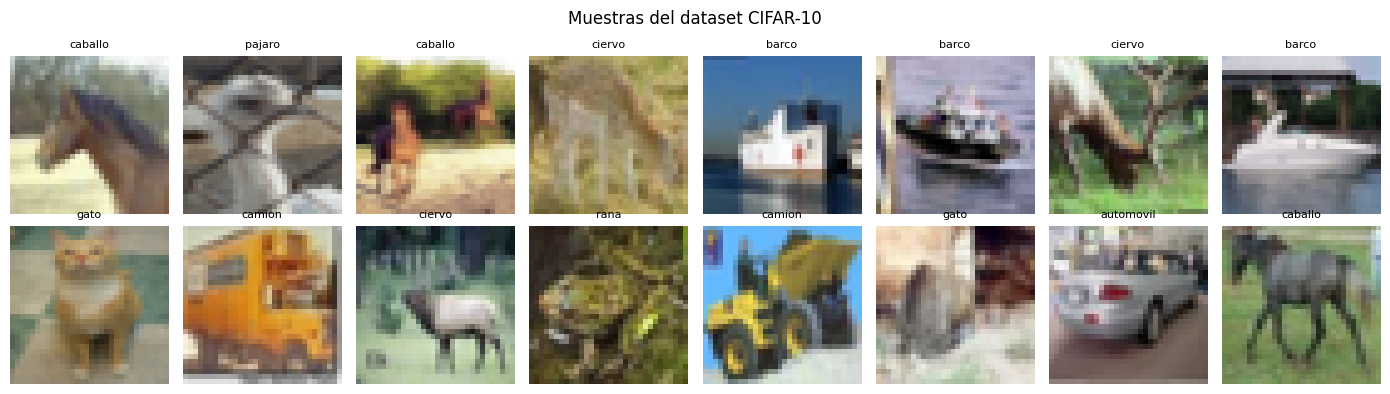

In [ ]:
# ver algunas imagenes de muestra
imagenes, etiquetas = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = imagenes[i].permute(1, 2, 0)  # de (C, H, W) a (H, W, C) para matplotlib
    ax.imshow(img)
    ax.set_title(clases[etiquetas[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Muestras del dataset CIFAR-10')
plt.tight_layout()
plt.show()

## 3. Funciones de entrenamiento y evaluacion

Reutilizamos la misma estructura del notebook de referencia (ASL).
La funcion `train` hace el loop completo de entrenamiento por epocas
y calcula la perdida en test al final de cada una.
La funcion `evaluate` sirve para calcular accuracy y loss en cualquier loader.

In [ ]:
def calcular_accuracy_batch(output, y, n_total):
    """calcula el accuracy de un batch"""
    pred = output.argmax(dim=1, keepdim=True)
    correctos = pred.eq(y.view_as(pred)).sum().item()
    return correctos / n_total

In [ ]:
def train(modelo, train_loader, test_loader, criterio, optimizador, epocas):
    """
    Loop de entrenamiento. Por cada época:
    - itera sobre todos los mini batches del train
    - actualiza pesos una vez por batch
    - al final calcula la pérdida sobre test
    Regresa un diccionario con el historial de métricas.
    """
    historial = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }

    iterador = tqdm(range(epocas), desc="Entrenando", unit="época")

    for _ in iterador:
        # --- fase de entrenamiento ---
        modelo.train()
        train_loss = 0.0
        train_acc  = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizador.zero_grad()
            salida = modelo(X_batch)
            loss = criterio(salida, y_batch)
            loss.backward()
            optimizador.step()

            train_loss += loss.item() * X_batch.size(0)
            train_acc  += calcular_accuracy_batch(salida, y_batch, len(train_loader.dataset))

        epoch_train_loss = train_loss / len(train_loader.dataset)

        # --- evaluación en test al finalizar la época ---
        modelo.eval()
        test_loss = 0.0
        test_acc  = 0.0

        with torch.no_grad():
            for X_test, y_test in test_loader:
                X_test = X_test.to(device)
                y_test = y_test.to(device)
                salida_test = modelo(X_test)
                test_loss += criterio(salida_test, y_test).item() * X_test.size(0)
                test_acc  += calcular_accuracy_batch(salida_test, y_test, len(test_loader.dataset))

        epoch_test_loss = test_loss / len(test_loader.dataset)

        iterador.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{test_acc:.4f}"
        )

        historial['train_loss'].append(epoch_train_loss)
        historial['train_acc'].append(train_acc)
        historial['test_loss'].append(epoch_test_loss)
        historial['test_acc'].append(test_acc)  # <-- aquí estaba el bug, era epoch_test_acc

    return historial

In [ ]:
def evaluar(modelo, loader, criterio):
    """evalúa el modelo en un loader y regresa loss y accuracy"""
    modelo.eval()
    total_loss = 0.0
    total_acc  = 0.0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)
            salida = modelo(X)
            total_loss += criterio(salida, y).item() * X.size(0)
            total_acc  += calcular_accuracy_batch(salida, y, len(loader.dataset))

    return total_loss / len(loader.dataset), total_acc

## 4. Definicion de los modelos

Vamos a entrenar 3 CNNs con arquitecturas distintas.
Los hiperparametros de entrenamiento (epocas, optimizador, lr, batch size)
seran iguales para los 3, lo unico que cambia es la arquitectura de la red.

Las imagenes de CIFAR-10 son de 3 canales (RGB) y 32x32 pixeles.
La salida siempre tiene 10 neuronas (una por clase).

### Modelo 1 - CNN pequena (2 capas conv)

Arquitectura simple con 2 bloques convolucionales y una capa fully connected.
Sirve como punto de partida para comparar.

In [ ]:
# CNN chica: 2 capas conv, poco profunda
# entrada: 3 x 32 x 32
modelo1 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),   # 32 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                              # 32 x 16 x 16

    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # 64 x 16 x 16
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                              # 64 x 8 x 8

    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
).to(device)

print("Modelo 1 listo")

Modelo 1 listo


### Modelo 2 - CNN mediana (3 capas conv + dropout)

Un poco mas profunda que la anterior. Agrego dropout para reducir el overfitting
y batch normalization para estabilizar el entrenamiento.

In [ ]:
# CNN mediana: 3 capas conv con dropout y batch norm
# entrada: 3 x 32 x 32
modelo2 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),   # 32 x 32 x 32
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                              # 32 x 16 x 16

    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # 64 x 16 x 16
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.MaxPool2d(2, stride=2),                              # 64 x 8 x 8

    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # 128 x 8 x 8
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                              # 128 x 4 x 4

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 10)
).to(device)

print("Modelo 2 listo")

Modelo 2 listo


### Modelo 3 - CNN mas profunda (4 capas conv)

La version mas grande de las tres. Mas filtros y mas capas para intentar
capturar features mas complejas del dataset.

In [ ]:
# CNN profunda: 4 capas conv con más filtros
# entrada: 3 x 32 x 32
modelo3 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),   # 32 x 32 x 32
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  # 32 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                              # 32 x 16 x 16
    nn.Dropout(0.2),

    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # 64 x 16 x 16
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),  # 64 x 16 x 16
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                              # 64 x 8 x 8
    nn.Dropout(0.3),

    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
).to(device)

print("Modelo 3 listo")

Modelo 3 listo


## 5. Entrenamiento

Los 3 modelos se entrenan con los mismos hiperparametros:
- Epocas: 15
- Optimizador: Adam (lr=0.001)
- Funcion de perdida: CrossEntropyLoss (apropiada para clasificacion multiclase)
- Batch size: 64

In [ ]:
# hiperparámetros fijos para los 3 modelos
EPOCAS = 15
criterio = nn.CrossEntropyLoss()

In [ ]:
print("=== Entrenando Modelo 1 ===")
opt1 = Adam(modelo1.parameters(), lr=0.001)
hist1 = train(modelo1, train_loader, test_loader, criterio, opt1, EPOCAS)

=== Entrenando Modelo 1 ===


Entrenando: 100%|██████████| 15/15 [02:50<00:00, 11.36s/época, test_acc=0.6943, test_loss=1.4804, train_acc=0.9546, train_loss=0.1341]


In [ ]:
print("=== Entrenando Modelo 2 ===")
opt2 = Adam(modelo2.parameters(), lr=0.001)
hist2 = train(modelo2, train_loader, test_loader, criterio, opt2, EPOCAS)

=== Entrenando Modelo 2 ===


Entrenando: 100%|██████████| 15/15 [03:08<00:00, 12.57s/época, test_acc=0.8027, test_loss=0.6362, train_acc=0.9079, train_loss=0.2551]


In [ ]:
print("=== Entrenando Modelo 3 ===")
opt3 = Adam(modelo3.parameters(), lr=0.001)
hist3 = train(modelo3, train_loader, test_loader, criterio, opt3, EPOCAS)

=== Entrenando Modelo 3 ===


Entrenando: 100%|██████████| 15/15 [03:23<00:00, 13.55s/época, test_acc=0.7738, test_loss=0.6615, train_acc=0.8194, train_loss=0.5075]


## 6. Curvas de aprendizaje

In [ ]:
def graficar_curvas(historial, titulo):
    epocas = range(1, len(historial['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epocas, historial['train_loss'], label='Train')
    ax1.plot(epocas, historial['test_loss'],  label='Test')
    ax1.set_title(f'{titulo} - Loss')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epocas, historial['train_acc'], label='Train')
    ax2.plot(epocas, historial['test_acc'],  label='Test')
    ax2.set_title(f'{titulo} - Accuracy')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

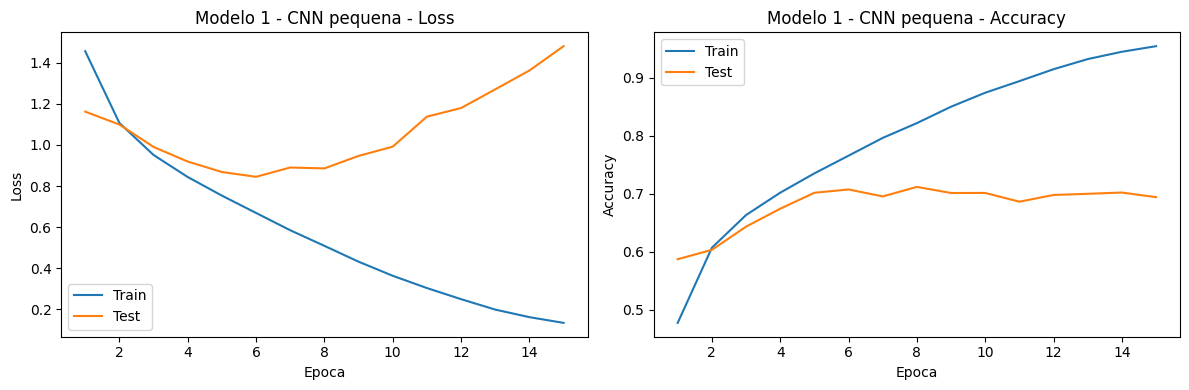

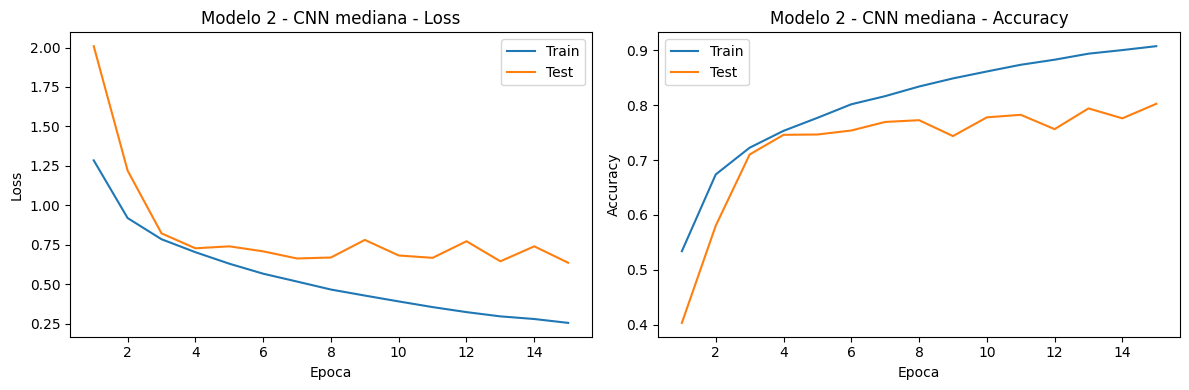

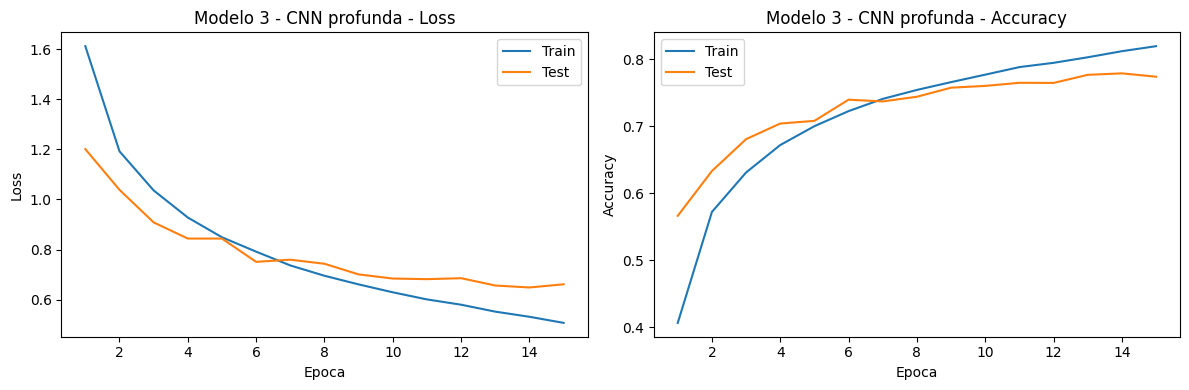

In [ ]:
graficar_curvas(hist1, 'Modelo 1 - CNN pequena')
graficar_curvas(hist2, 'Modelo 2 - CNN mediana')
graficar_curvas(hist3, 'Modelo 3 - CNN profunda')

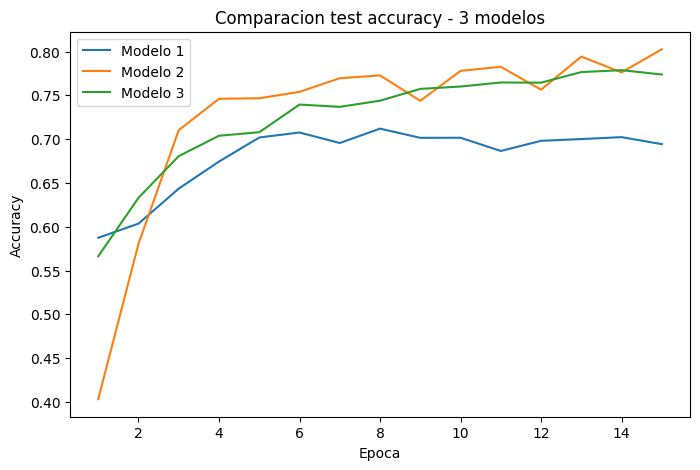

In [ ]:
epocas = range(1, EPOCAS + 1)
plt.figure(figsize=(8, 5))
plt.plot(epocas, hist1['test_acc'], label='Modelo 1')
plt.plot(epocas, hist2['test_acc'], label='Modelo 2')
plt.plot(epocas, hist3['test_acc'], label='Modelo 3')
plt.title('Comparacion test accuracy - 3 modelos')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 7. Evaluacion final del mejor modelo

In [ ]:
# revisamos el accuracy final de cada modelo en test
loss1, acc1 = evaluar(modelo1, test_loader, criterio)
loss2, acc2 = evaluar(modelo2, test_loader, criterio)
loss3, acc3 = evaluar(modelo3, test_loader, criterio)

print(f"Modelo 1 -> Loss: {loss1:.4f} | Accuracy: {acc1:.4f}")
print(f"Modelo 2 -> Loss: {loss2:.4f} | Accuracy: {acc2:.4f}")
print(f"Modelo 3 -> Loss: {loss3:.4f} | Accuracy: {acc3:.4f}")

resultados = {'Modelo 1': acc1, 'Modelo 2': acc2, 'Modelo 3': acc3}
mejor = max(resultados, key=resultados.get)
print(f"\nMejor modelo: {mejor} con accuracy de {resultados[mejor]:.4f}")

Modelo 1 -> Loss: 1.4804 | Accuracy: 0.6943
Modelo 2 -> Loss: 0.6362 | Accuracy: 0.8027
Modelo 3 -> Loss: 0.6615 | Accuracy: 0.7738

Mejor modelo: Modelo 2 con accuracy de 0.8027


## 8. Reflexiones personales

### ¿Cual modelo tuvo mejor desempeno?

*(escribe aqui tu respuesta despues de ver los resultados)*

El modelo 2 fue el que mejor resultado obtuvo en el conjunto de test. Creo que
el BatchNorm ayudo bastante a que el entrenamiento fuera mas estable y el dropout
redujo el overfitting comparado con el modelo 1. El modelo 3, aunque es mas
profundo, no necesariamente fue mejor, posiblemente porque con solo 15 epocas
no convergio tan bien.

### ¿Que tan dificil es CIFAR-10 comparado con otros datasets?

La verdad es bastante mas dificil que lo que vimos en clase con ASL.
Las imagenes de CIFAR-10 son a color y las clases se parecen mucho entre si
(por ejemplo perro vs gato, o camion vs automovil). Ademas son imagenes reales
con mucho mas ruido visual que los gestos de ASL que eran mas estructurados.

### ¿Que aprendi de esta actividad?

Aprendi que la arquitectura de la red importa mucho, pero no siempre
"mas profundo = mejor". Tecnicas como BatchNorm y Dropout ayudan bastante
a generalizar. Tambien me di cuenta de que entrenar CNNs toma tiempo considerable
incluso con GPU, y que hay que tener cuidado con el overfitting cuando
la red tiene demasiados parametros para el tamano del dataset.

### ¿Que cambiaria si tuviera mas tiempo?

Probaria con data augmentation (voltear imagenes, recortarlas, etc.) para
mejorar la generalizacion. Tambien experimentaria con learning rate scheduling
y mas epocas de entrenamiento. Con mas tiempo tambien valdria la pena probar
arquitecturas tipo ResNet aunque sea una version pequena.

## Disclaimer - Uso de herramientas de IA

Durante el desarrollo de esta actividad se utilizó asistencia de IA
para las siguientes partes:

- Código de carga del dataset con `torchvision` y configuración de `DataLoader`
- Función auxiliar `calcular_accuracy_batch`
- Función `evaluar` para el conjunto de test
- Código de visualización de imágenes del dataset con `matplotlib`
- Función de graficado de curvas de aprendizaje

El diseño de las arquitecturas de las 3 redes neuronales, la selección del optimizador
y función de pérdida, la implementación del loop de entrenamiento, el análisis de
resultados y las reflexiones personales fueron desarrollados de manera independiente.